In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt


In [2]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
start_of_sentence =" "

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [29]:
def p1_new(dialog, start_of_sentence):
    max_length = model.config.n_positions
    stride = 1
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)
    nlls = []
    for end_loc in tqdm(range(1, seq_len + 1, stride)):
        begin_loc = max(end_loc - max_length, 0)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-stride] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood.item())

    return nlls

In [23]:
def create_extended_list(lst, arr):
    result = []
    prev_count = 0
    for i, count in enumerate(arr):
        result.extend([lst[i]] * (count - prev_count))
        prev_count = count
    return result

def compute_p3(dialog, perplexity_scores_p1, pattern = '<(SPK[1-9]|MOD)>'):
    assert len(perplexity_scores_p1) == tokenizer(" ".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)
    tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
    assert len(torch.cat(tokens)) == len(perplexity_scores_p1)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    value = np.asarray([0] + list(np.asarray(perplexity_scores_p1)[tokens_ids_per_sentence[:-1]]))
    tokens_value = np.asarray([0] + list(np.asarray(torch.cat(tokens))[tokens_ids_per_sentence[:-1]]))
    perplexity_scores_p3 = create_extended_list(value, tokens_ids_per_sentence)
    assert len(perplexity_scores_p3) == tokenizer(" ".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)

    return perplexity_scores_p3

In [11]:
def compute_graph_perplexity(tokens, p1, p2, matches, pattern = '<(SPK[1-9]|MOD)>', answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens]
    unique_matches = np.unique(matches)
    
    rows = int(np.ceil(np.sqrt(len(dialog))))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, rows, figsize=(30, 30))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} p1')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()

In [5]:
el=" <SPK1> So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. <SPK1> Ok, sounds good. <SPK1> Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, <SPK2> ? <SPK2> Mhmm… um, ambulance? <SPK1> Correct, and can you guess the next two most popular answers? <SPK2> Hmm... wheelchair? <SPK1> Yes, good! And the third one? <SPK2> Maybe... a stretcher? <SPK1> Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? <SPK2> Uh… beach resorts? <SPK1> Yes, that’s number one! What about number two? <SPK2> Mountain retreat? <SPK1> Exactly. And number three? <SPK2> Uh… city stays? <SPK1> Perfect! Now we have the last one: What is the most common drink people enjoy at breakfast? Can you guess? <SPK2> Coffee? <SPK1> Right! What else? <SPK2> Maybe... juice? <SPK1> Correct! And the third one? <SPK2> Milk? <SPK1> Yes, that’s exactly right! Well done! You got all the answers!"
display(el)

" <SPK1> So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. <SPK1> Ok, sounds good. <SPK1> Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, <SPK2> ? <SPK2> Mhmm… um, ambulance? <SPK1> Correct, and can you guess the next two most popular answers? <SPK2> Hmm... wheelchair? <SPK1> Yes, good! And the third one? <SPK2> Maybe... a stretcher? <SPK1> Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? <SPK2> Uh… beach resorts? <SPK1> Yes, that’s 

In [42]:
# Make a copy of text
turn_based_el = el

# Speaker patterns
pattern='<(SPK[1-9]|MOD)>'

# Find duplicated consequative speakers to remove
speaker_tags_to_remove = []
last_match = None
for match in re.compile(pattern).finditer(el):
    if match.group() == last_match:
        speaker_tags_to_remove.append((match.start(), match.end()))
    last_match = match.group()
speaker_tags_to_remove = sorted(speaker_tags_to_remove, reverse=True)

# Remove duplicated consequative speakers
for begin, end in speaker_tags_to_remove:
    turn_based_el = turn_based_el[:begin] + turn_based_el[end:]

# find matches and change speaker format
matches = re.findall(pattern, "".join(turn_based_el))
dialog = re.sub(r'\<', r'\n<', turn_based_el).split("\n")[1:]
dialog = [d.strip() for d in dialog]
dialog_no_s = [re.sub(pattern,">", d) for d in dialog]
display(dialog_no_s)

["> So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people.  Ok, sounds good.  Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say,",
 '> ?  Mhmm… um, ambulance?',
 '> Correct, and can you guess the next two most popular answers?',
 '> Hmm... wheelchair?',
 '> Yes, good! And the third one?',
 '> Maybe... a stretcher?',
 "> Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three?",
 '> Uh… beach resorts?',
 '> Yes, that’s number one! What about number t

In [43]:
perplexity_scores_p1 = p1_new(dialog_no_s, start_of_sentence=" ")
assert tokenizer(" ".join(dialog_no_s), return_tensors="pt").input_ids.size(1), len(perplexity_scores_p1)


100%|██████████| 324/324 [00:06<00:00, 51.79it/s]


In [45]:
perplexity_scores_p3 = compute_p3(dialog_no_s, perplexity_scores_p1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


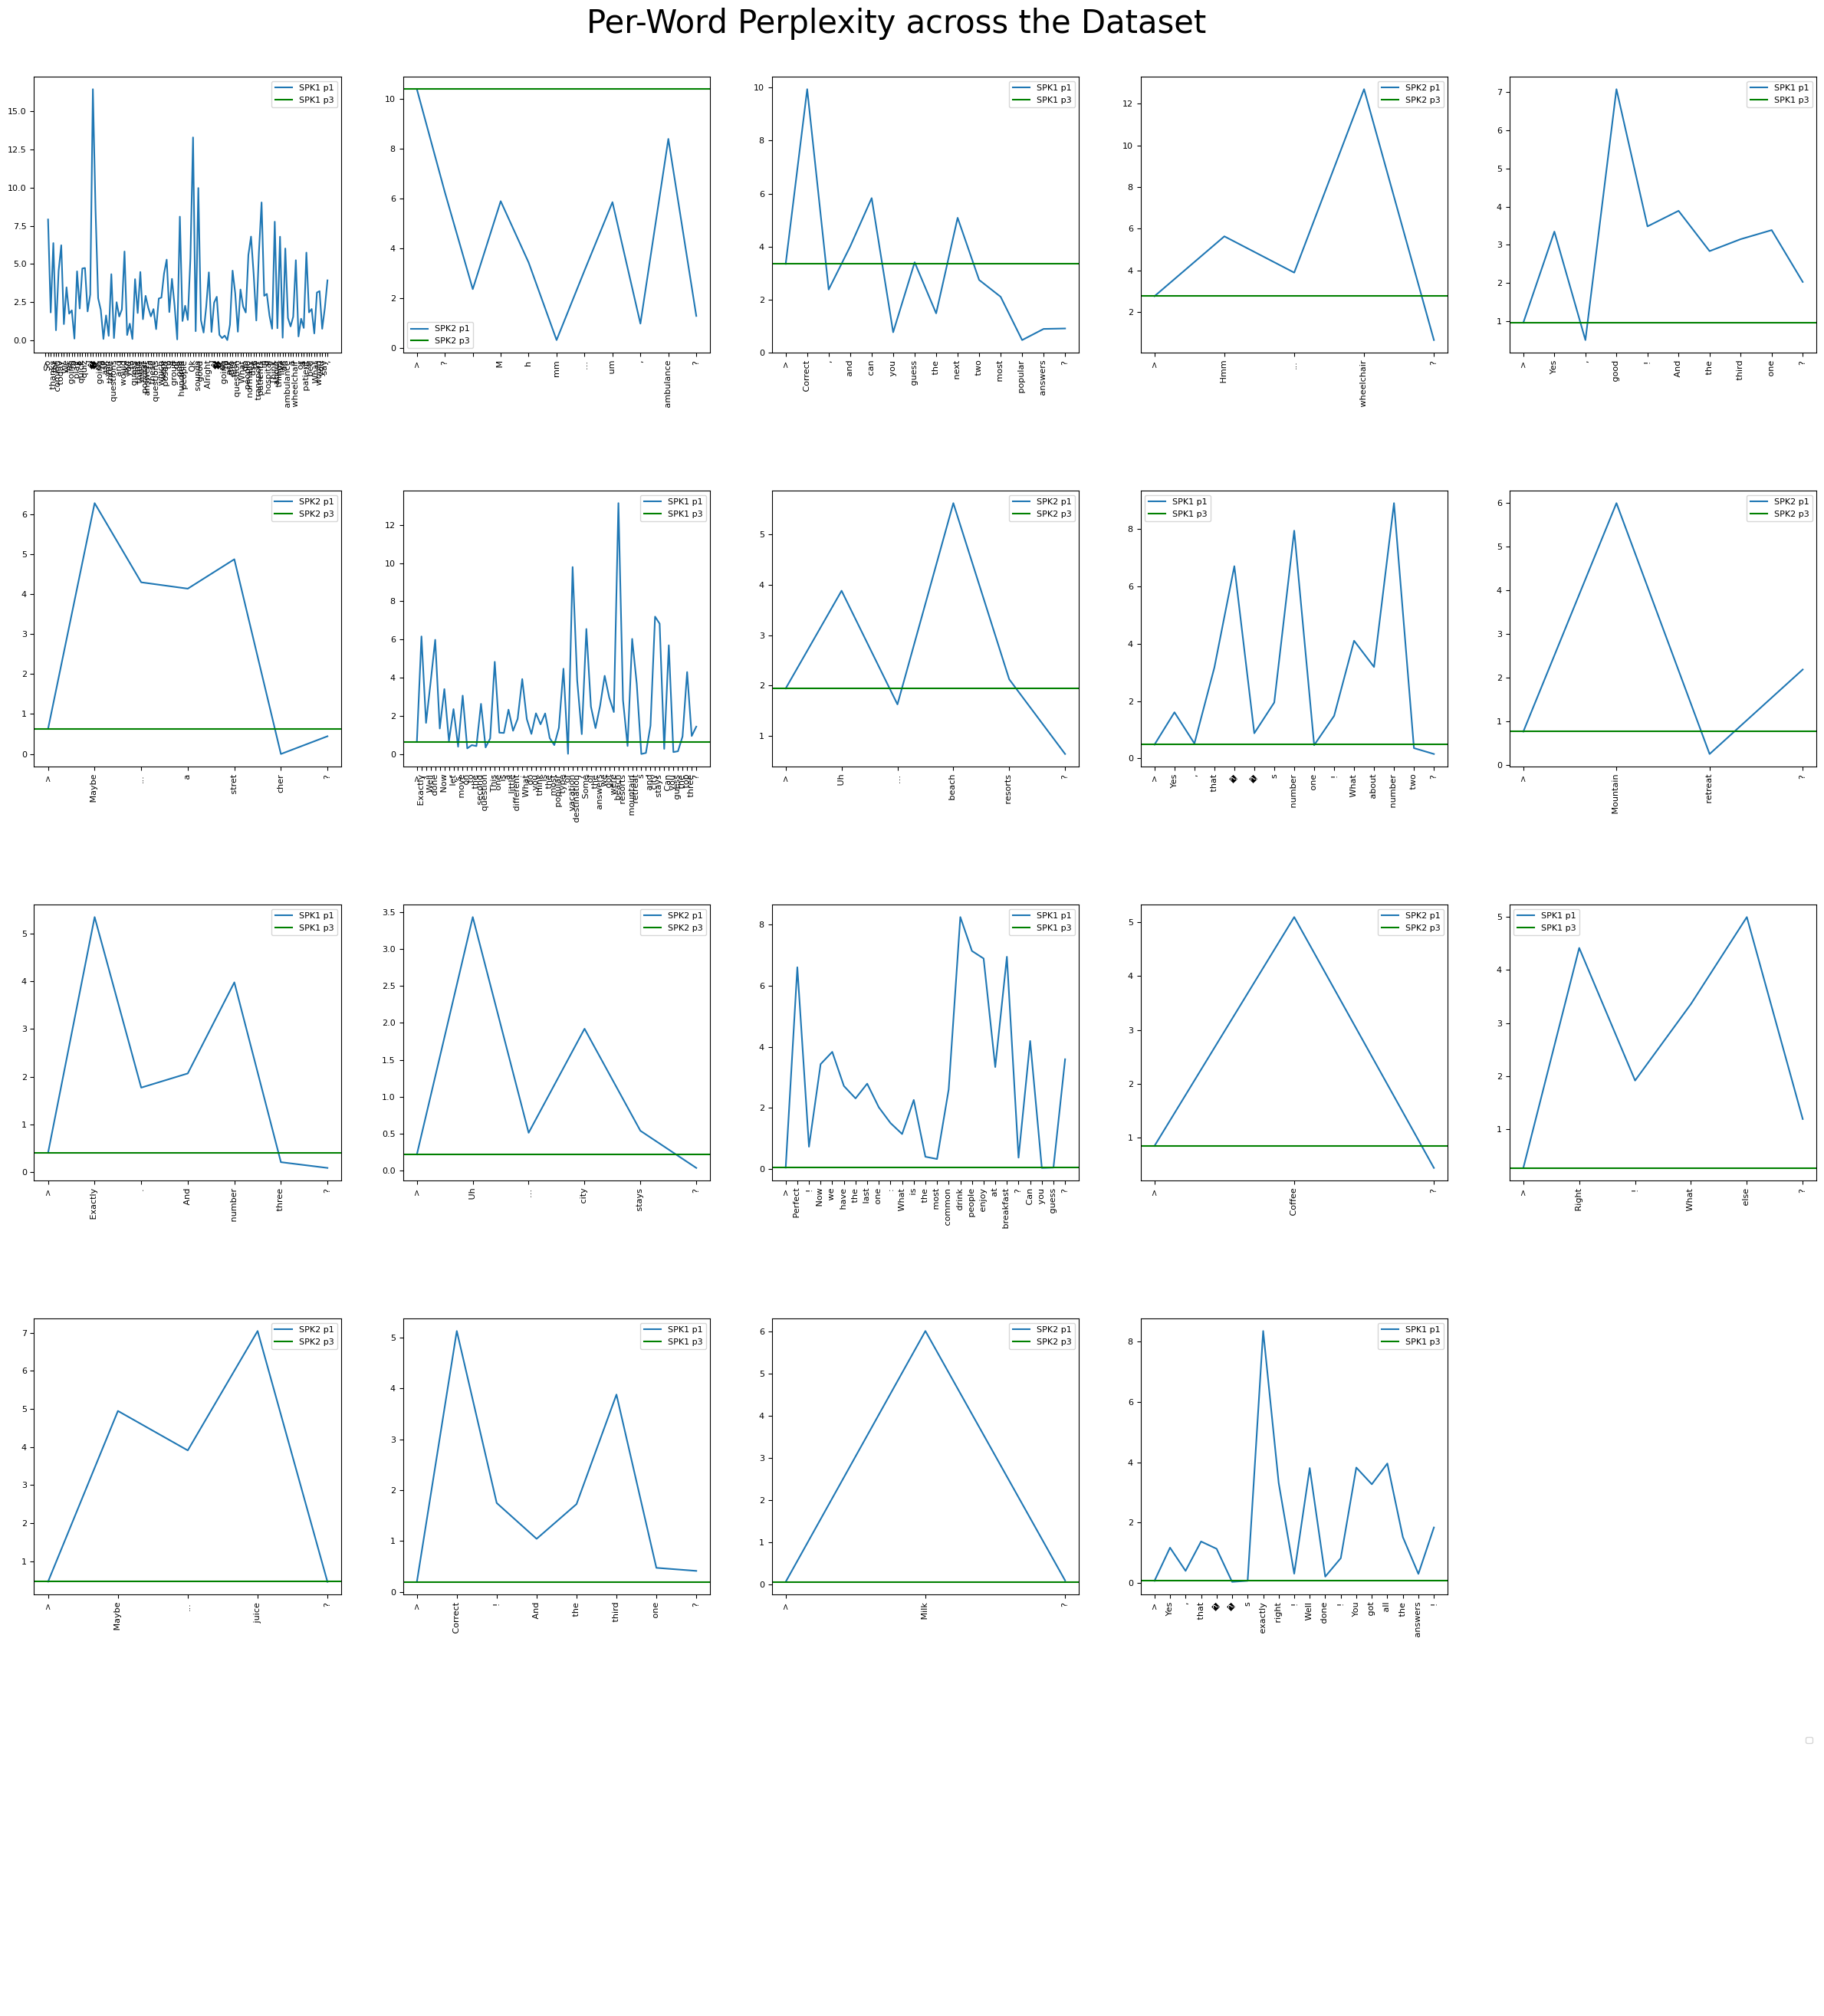

In [46]:
assert len(perplexity_scores_p1) == tokenizer(" ".join(dialog_no_s), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)
tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog_no_s]
assert len(torch.cat(tokens)) == len(perplexity_scores_p1)
compute_graph_perplexity(tokens, perplexity_scores_p1, perplexity_scores_p3, matches, pattern=pattern) 

In [47]:
np.corrcoef(perplexity_scores_p1[1:], perplexity_scores_p3[1:])

array([[1.        , 0.12510217],
       [0.12510217, 1.        ]])